Created 4/25/2022 

plot all models onto one graph based on mse - based on the experiment. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [2]:
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contexpNoStimLoc/")

NameError: name 'modelerr' is not defined

In [ ]:
base = "Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/contexp/"
full_files = getfiles(base)

In [ ]:
p = Precision()
p.mult_models(full_files)

In [3]:
def getfiles(base):
    files = os.listdir(base)
    files = [f for f in files if 'Base.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' not in f]
    print(len(full_files))
    return full_files

def getlcfiles(base):
    files = os.listdir(base)
    files = [f for f in files if '.csv' in f]
    full_files = [base+f for f in files if 'EpcLog' in f]
    return full_files
    

def geterror(base):
    full_files = getfiles(base)
    num_models = len(full_files)
    p = Precision()
    L1_means = np.zeros(num_models)
    L1_vars = np.zeros(num_models)
    for f in range(len(full_files)):
        err_model = p.mult_models([full_files[f]])
        L1 = np.abs(err_model)
        L1_means[f]=np.mean(L1)
        L1_vars[f] = np.var(L1)
    #mse = np.sqrt(np.mean(err**2)) 
    total_mean = np.mean(L1_means)
    total_var = np.mean(L1_vars)/num_models
    errorbar_std = np.std(L1_means)/np.sqrt(num_models)
    return err_model, total_mean, total_var, errorbar_std
    
def getlc(base):
    full_files = getlcfiles(base)
    num_models = len(full_files)
    SSE=[]
    Epoch = []
    for f in full_files:
        if 'model0_' in f:
            df = pd.read_csv(f, sep = '\t')
            SSE.append(df['#SSE'])
            Epoch.append(df['|Epoch'])
        else:
            df = pd.read_csv(f,sep = '\t', header = None)
            SSE.append(df[2])
    SSE_np = np.array(SSE)
    SSE_avg = np.mean(SSE_np, axis = 0)
    SSE_std = np.std(SSE_np, axis = 0)/np.sqrt(num_models)
    #plt.plot(Epoch[0],SSE_avg)
    
    return Epoch[0], SSE_avg, SSE_std 
    

def geterror_array(base):
    full_files = getfiles(base)
    p = Precision()
    err = p.mult_models(full_files)
    return err

def plot_title(base):
    
    if 'contexp' in base:
        rewardtype = 'Continuous Exponential'
    elif 'RewThresh' in base:
        rewardtype = 'Binary'
    else:
        rewardtype = 'Continuous Linear'
        
    if 'decodedrew' in base:
        rewardfun = 'Decoded'
    else: 
        rewardfun = 'Unit Difference'
        
    if 'NoStimLoc' in base:
        stimloc = ', No Stim Loc'
    else: 
        stimloc = ", Stim Loc Used"
   
    if 'NoIgnore' in base:
        ignore = ', No Ignore Trials'
    else:
        ignore = ''

    if "StimRange0to45" in base:
        stim_dist = ', StimDist Max 45'
    else:
        stim_dist = ""


    title = 'Reward Function: ' + rewardtype +', ' +rewardfun +stimloc + ignore +stim_dist#+' '+additional_title
    return title

def find_a(var, J, n):
    a = math.log(1/(var*J), Base = n)  
    return a


def mse_allmodels(base, base2, experiment, plot_errorbars = True, sir4 = False, sep_experiments = []):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    if len(sep_experiments)> 0:
        sir2_file = base + "sir2_new/" +base2+sep_experiments[0]
        sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+sep_experiments[0]
        sir3_file = base + "sir3/" +base2+sep_experiments[1]
        sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+sep_experiments[1]
        sir4_file = base + "sir4/" +base2+sep_experiments[2]
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+sep_experiments[2]
        print(sir2_file)
        print(sir3_file)
        print(sir4_file)
        
    
    err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
    err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
    err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file)
    err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
    err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file)
    err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
    
#   a2 = find_a(1-err_sir2,)
#     a2_chunk = find_a(1-err_sir2_chunk,)
#     a3 = find_a(1-err_sir3)
#     title = plot_title(sir2_file)
#     title = title+"/n a values for sir2: {:.2f}, sir3: {:.2f}, sir2_chunk: {:.2f}, sir3_chunk {:.2f}".format(a2, a3, a2_chunk, a3_chunk)

    title = plot_title(sir2_file)
    if sir4:
        tasks = [2,3,4]
        mse_all_nochunk = [mse_sir2,mse_sir3,mse_sir4]
        std_all_nochunk = [std_sir2,std_sir3, std_sir4]
        
        mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk,mse_sir4_chunk]
        std_all_chunk = [std_sir2_chunk,std_sir3_chunk,std_sir4_chunk]
        
        plt.xlim(1.8,4.2)
    else:
        tasks = [2,3]
        mse_all_nochunk = [mse_sir2,mse_sir3]
        std_all_nochunk = [std_sir2,std_sir3]
        
        mse_all_chunk = [mse_sir2_chunk,mse_sir3_chunk]
        std_all_chunk = [std_sir2_chunk,std_sir3_chunk]
   
        plt.xlim([1.8,3.2])
    
    if plot_errorbars == True:
        plt.errorbar(tasks,mse_all_nochunk,std_all_nochunk, color = "blue")
        plt.errorbar(tasks,mse_all_chunk, std_all_chunk, color = "yellow")
    else:
        plt.plot(tasks,mse_all_nochunk)
        plt.plot(tasks,mse_all_chunk)

#         if plot_errorbars == True:
#             plt.errorbar([2,3],[mse_sir2,mse_sir3], [std_sir2,std_sir3])
#             plt.errorbar([2,3],[mse_sir2_chunk,mse_sir3_chunk], [std_sir2_chunk,std_sir3_chunk])
#         else:
#             plt.plot([2,3],[mse_sir2,mse_sir3])
#             plt.plot([2,3],[mse_sir2_chunk,mse_sir3_chunk])
#         plt.xticks([2,3])
#         plt.xlim([1.8,3.2])
        
    plt.xticks(tasks)
    plt.ylabel('Absolute Error Averaged over Models')
    #plt.ylabel(r'$\sqrt{MSE}$')
    plt.xlabel('Number of Items')
    plt.legend(['No Chunk', 'Chunk'], loc = 'lower right')
    plt.title(title)
    
    plt.figure()
    #percent imrpovement for chunk model over the no chunk model. 
    task2 = (np.abs(mse_sir2-mse_sir2_chunk)/mse_sir2)*100
    task3 = (np.abs(mse_sir3-mse_sir3_chunk)/mse_sir3)*100
    plt.bar(['Task 2', 'Task 3'], [task2, task3])
    
def lc_allmodels(base,base2,experiment, plot_errorbars = True, sir4 = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    _, SSE_sir2, std_sir2 = getlc(sir2_file)
    _, SSE_sir2_chunk, std_sir2_chunk = getlc(sir2_chunk_file)
    _, SSE_sir3, std_sir3 = getlc(sir3_file)
    Epoch, SSE_sir3_chunk, std_sir3_chunk = getlc(sir3_chunk_file)
    if sir4:
        _, SSE_sir4, std_sir4 = getlc(sir4_file)
        _, SSE_sir4_chunk, std_sir4_chunk = getlc(sir4_chunk_file)
    
    title = plot_title(sir2_file)
    plt.figure()
    if plot_errorbars:
        plt.errorbar(Epoch,SSE_sir2,std_sir2)
        plt.errorbar(Epoch,SSE_sir2_chunk, std_sir2_chunk)

    else:
        plt.plot(Epoch,SSE_sir2)
        plt.plot(Epoch,SSE_sir2_chunk)
    
    plt.title(title+ ', SIR 2 Task')
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.legend(['No Chunk', 'Chunk'])
    
    plt.figure()
    if plot_errorbars:
        plt.errorbar(Epoch,SSE_sir3, std_sir3)
        plt.errorbar(Epoch,SSE_sir3_chunk, std_sir3_chunk)
    else:
        plt.plot(Epoch,SSE_sir3)
        plt.plot(Epoch,SSE_sir3_chunk)
        
    plt.title(title+ ', SIR 3 Task')
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.legend(['No Chunk', 'Chunk'])
    
    if sir4:
        plt.figure()
        if plot_errorbars:
            plt.errorbar(Epoch,SSE_sir4, std_sir4)
            plt.errorbar(Epoch,SSE_sir4_chunk, std_sir4_chunk)
        else:
            plt.plot(Epoch,SSE_sir4)
            plt.plot(Epoch,SSE_sir4_chunk)

        plt.title(title+ ', SIR 4 Task')
        plt.xlabel('Epoch')
        plt.ylabel('SSE')
        plt.legend(['No Chunk', 'Chunk'])

def plot_allhist(base,base2,experiment,sir4 = False):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
        
    
    title = plot_title(sir2_file)
    err = geterror_array(sir2_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 2, No Chunk, "+title)
    
    err = geterror_array(sir2_chunk_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 2, Chunk, "+title)
    
    err = geterror_array(sir3_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 3, No Chunk, "+title)
    
    err = geterror_array(sir3_chunk_file)
    plt.figure()
    plt.hist(err, bins = 50)
    plt.title("Task 3, Chunk, "+title)
    
    if sir4:
    
        err = geterror_array(sir4_file)
        plt.figure()
        plt.hist(err, bins = 50)
        plt.title("Task 3, No Chunk, "+title)

        err = geterror_array(sir4_chunk_file)
        plt.figure()
        plt.hist(err, bins = 50)
        plt.title("Task 4, Chunk, "+title)
    
    

def plot_var(base,base2,experiment, sir4 = False, pretrain = True):
    sir2_file = base + "sir2_new/" +base2+experiment
    sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
    sir3_file = base + "sir3/" +base2+experiment
    sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    if sir4:
        sir4_file = base + "sir4/" +base2+experiment
        sir4_chunk_file = base + "sir4_chunk/" +base2+"hybrid/"+experiment
    
    err_sir2, mse_sir2, var_sir2, std_sir2 = geterror(sir2_file)
    err_sir2_chunk, mse_sir2_chunk, var_sir2_chunk,std_sir2_chunk = geterror(sir2_chunk_file)
    err_sir3, mse_sir3, var_sir3,std_sir3 = geterror(sir3_file)
    err_sir3_chunk, mse_sir3_chunk, var_sir3_chunk,std_sir3_chunk = geterror(sir3_chunk_file)
    if sir4:
        err_sir4, mse_sir4, var_sir4,std_sir4 = geterror(sir4_file)
        err_sir4_chunk, mse_sir4_chunk, var_sir4_chunk,std_sir4_chunk = geterror(sir4_chunk_file)
        mod = ["SIR 2, No Chunk", "SIR 2, Chunk", "SIR 3, No Chunk", "SIR 3 Chunk", "SIR 4, No Chunk", "SIR 4, Chunk"]
        var = [var_sir2,var_sir2_chunk,var_sir3,var_sir3_chunk,var_sir4,var_sir4_chunk]
    else:
        mod = ["SIR 2, No Chunk", "SIR 2, Chunk", "SIR 3, No Chunk", "SIR 3 Chunk"]
        var = [var_sir2,var_sir2_chunk,var_sir3,var_sir3_chunk]
    
    plt.bar(mod,var)
    plt.xlabel('Model Type')
    plt.ylabel('Average Variance in Model')


# def plot_allhist_recalltype(base,base2,experiment)
#     sir2_file = base + "sir2_new/" +base2+experiment
#     sir2_chunk_file = base + "sir2_chunk/" +base2+"hybrid/"+experiment
#     sir3_file = base + "sir3/" +base2+experiment
#     sir3_chunk_file = base + "sir3_chunk/" +base2+"hybrid/"+experiment
    
    
        
#     for f in full_files:
#         err = Precision()
#         recall1,recall2,recall3=err.err_recall_type_sir3(f)
#         plt.figure()
#         model = f.split('/')[-1].split('_Stripes')[0]
#         plt.hist(recall1)
#         plt.title('Recall 1 Errors ,' +model)
#         plt.figure()
#         plt.hist(recall2)
#         plt.title('Recall 2 Errors ,'+model)
#         plt.figure()
#         plt.hist(recall3)
#         plt.title('Recall 3 Errors ,'+model)
#     return full_files


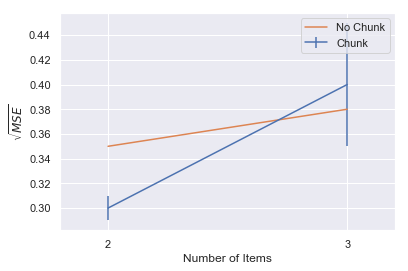

In [47]:
#NOT REAL DATA, trial for plotting purposes.
mse_sir2 = 0.3
mse_sir2_chunk = 0.35
mse_sir3 = 0.4
mse_sir3_chunk = 0.38
std_sir2 = 0.01
std_sir3 = 0.05

plt.errorbar([2,3],[mse_sir2,mse_sir3],[std_sir2,std_sir3])
plt.plot([2,3],[mse_sir2_chunk,mse_sir3_chunk])
plt.xticks([2,3])
plt.xlim([1.8,3.2])

plt.ylabel(r'$\sqrt{MSE}$')
plt.xlabel('Number of Items')
plt.legend(['No Chunk', 'Chunk'])

Y:/sir2_new/results/Ring/2Stripe//decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/
Y:/sir3/results/Ring/2Stripe//decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/
Y:/sir4/results/Ring/2Stripe//decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/
80
80
80
80
80
80


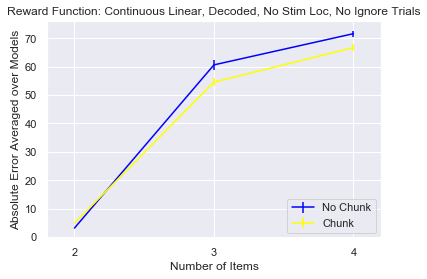

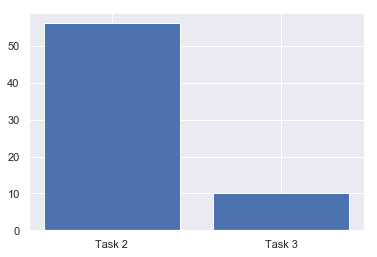

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
s2 = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
s3 = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
s4 = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
sep = [s2,s3,s4]
mse_allmodels(base,base2,experiment, sir4 =True, sep_experiments = sep)

160
160
160
160
160
160


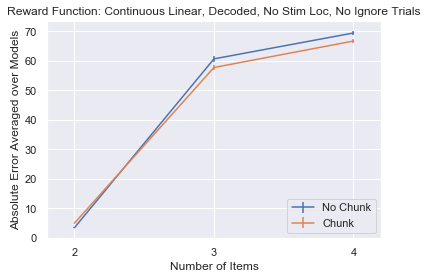

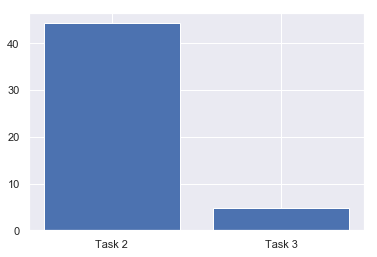

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
mse_allmodels(base,base2,experiment, sir4 =True)

Y:/sir2_new/results/Ring/2Stripe//decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/
Y:/sir3/results/Ring/2Stripe//decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/
Y:/sir4/results/Ring/2Stripe//decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/
80
80
80
80
80
80


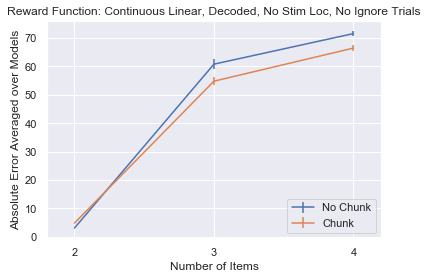

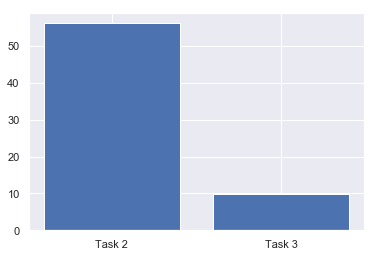

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
s2 = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
s3 = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
s4 = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
sep = [s2,s3,s4]
mse_allmodels(base,base2,experiment, sir4 =True, sep_experiments = sep)

80
80
80
80
80
80


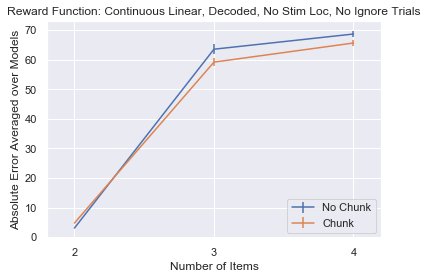

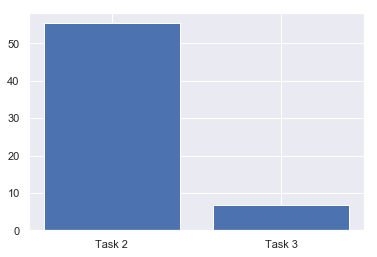

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate07/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


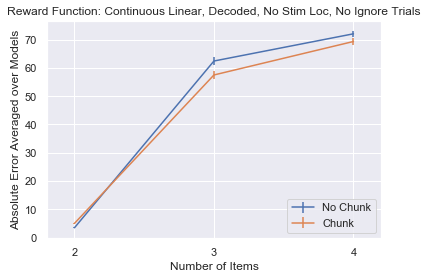

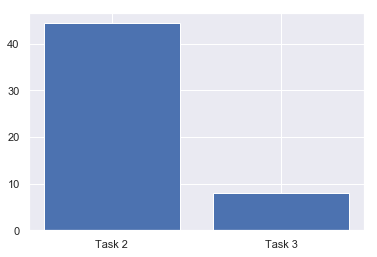

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate02/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


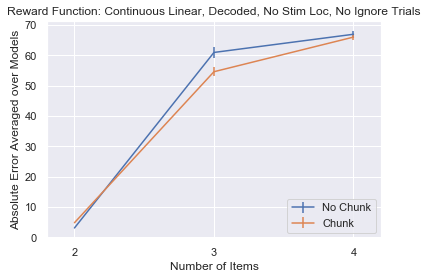

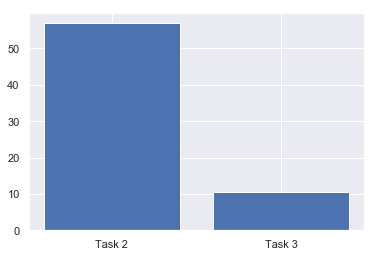

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


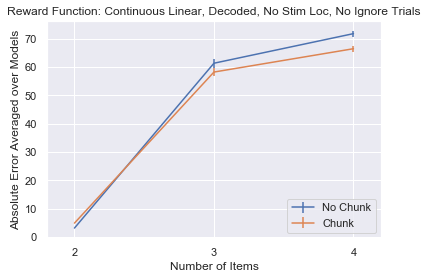

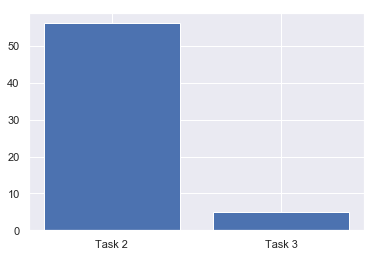

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
mse_allmodels(base,base2,experiment, sir4 =True)

81
82
80
80
80
80


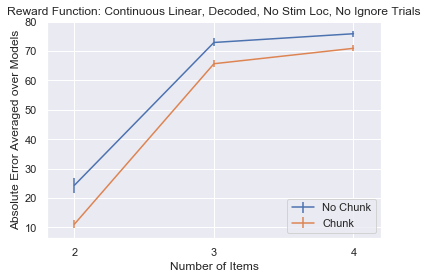

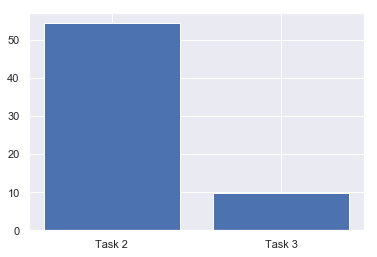

In [3]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


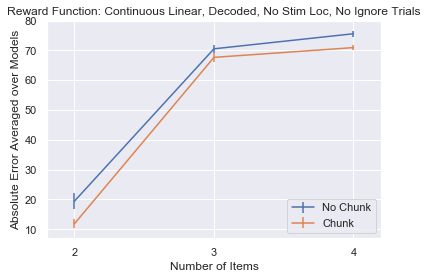

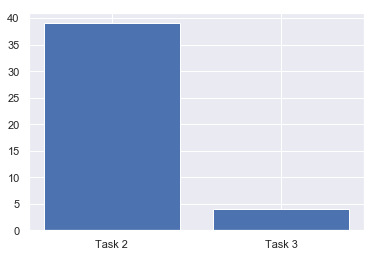

In [3]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG012/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


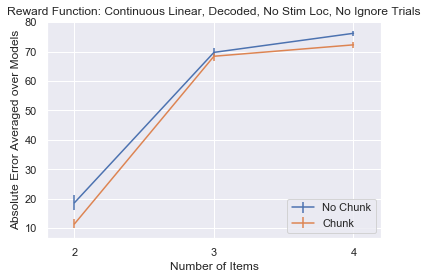

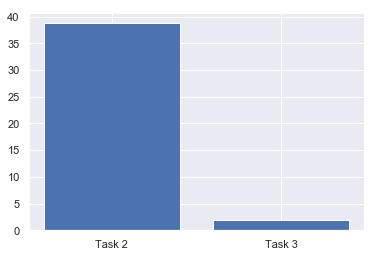

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG015/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


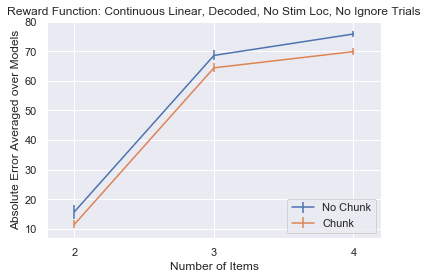

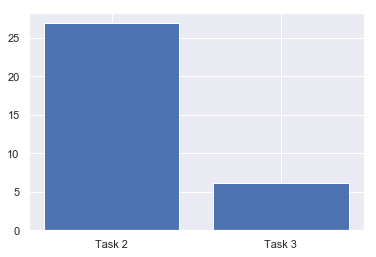

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG02/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


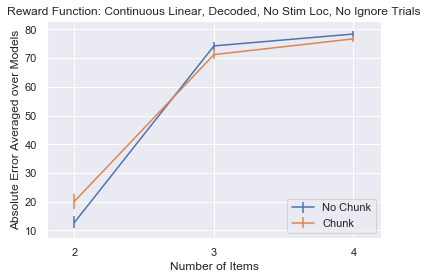

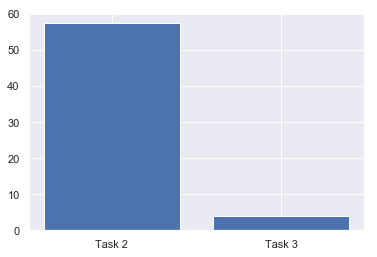

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG005/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


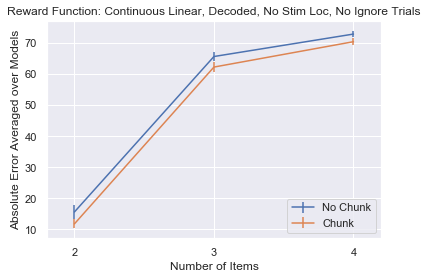

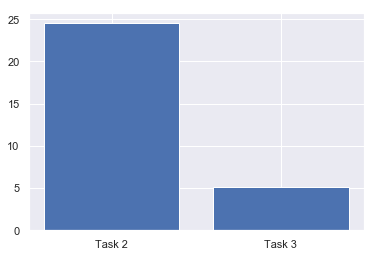

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG03/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


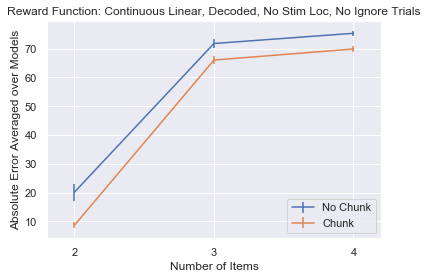

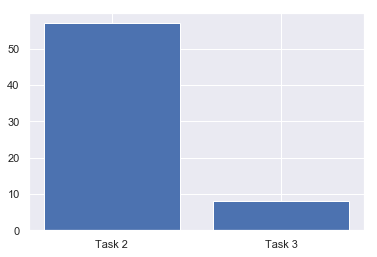

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


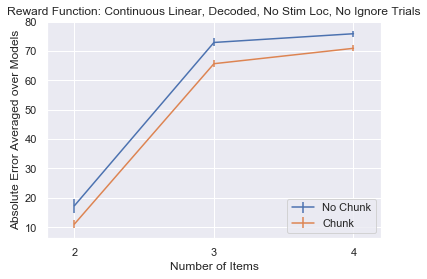

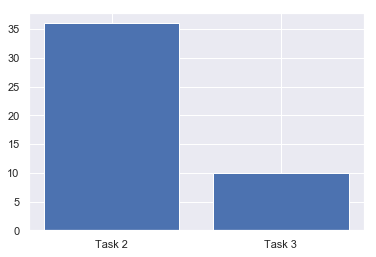

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


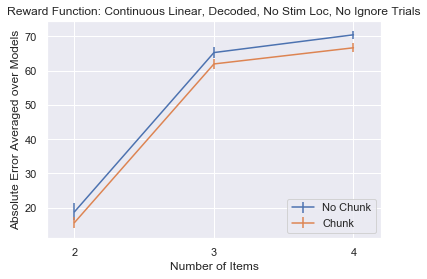

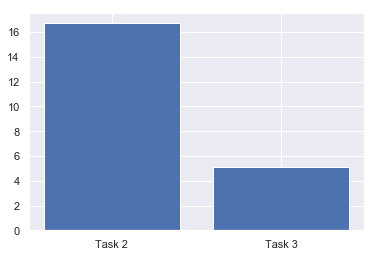

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG05/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


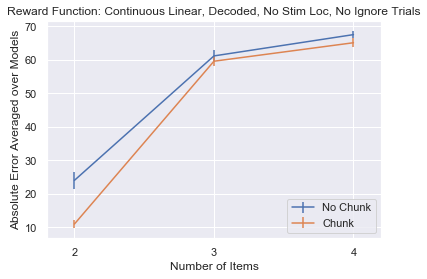

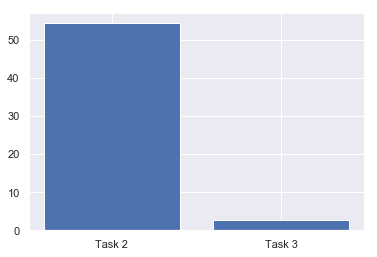

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG07/VmNoise/VarNonFixed/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


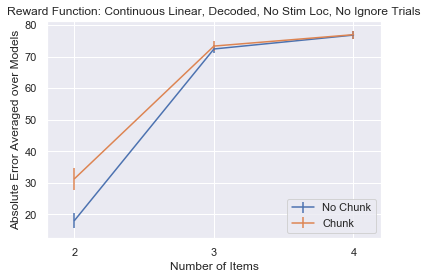

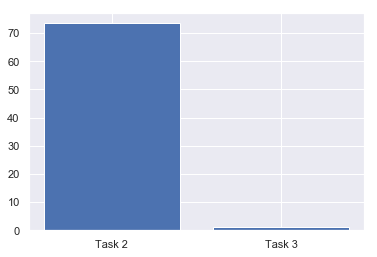

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG005/VmNoise/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


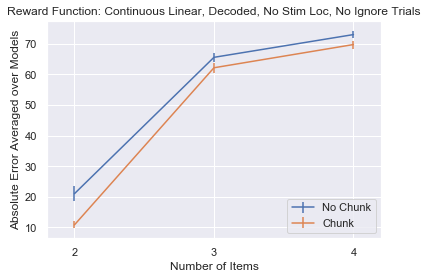

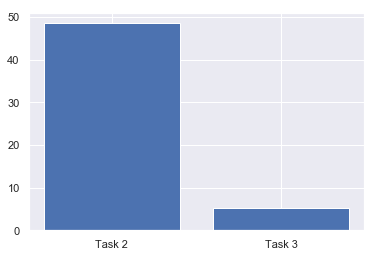

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG03/VmNoise/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


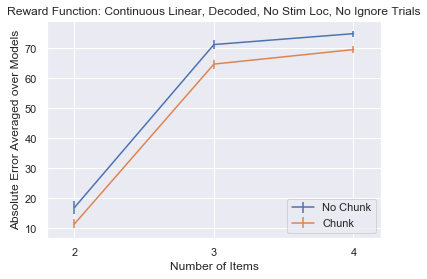

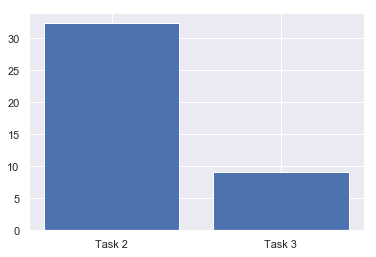

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


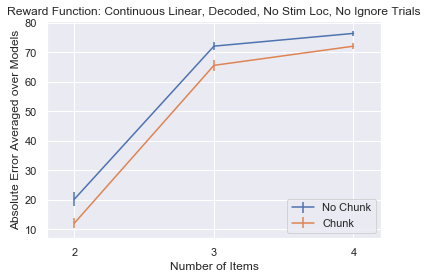

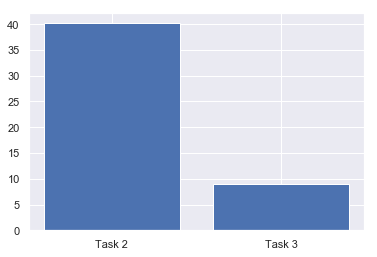

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise02/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
79


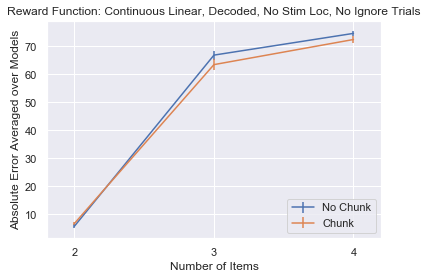

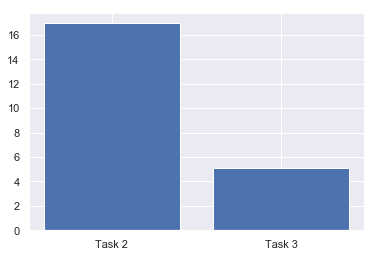

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


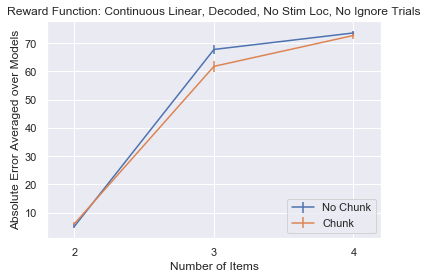

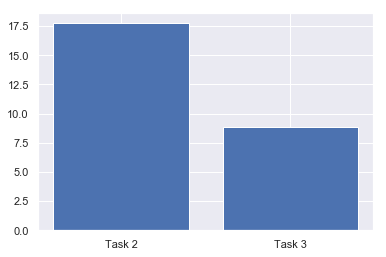

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise02/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


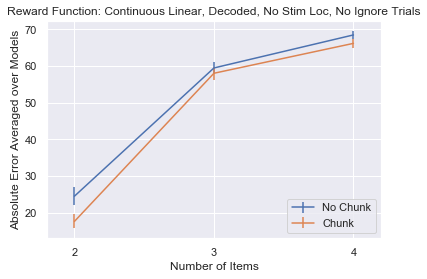

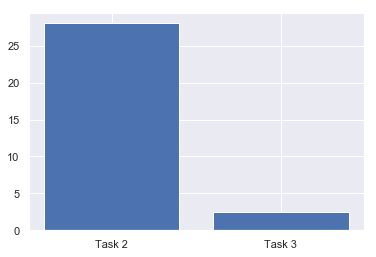

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/VmNoise/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


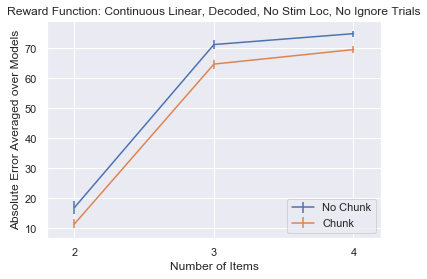

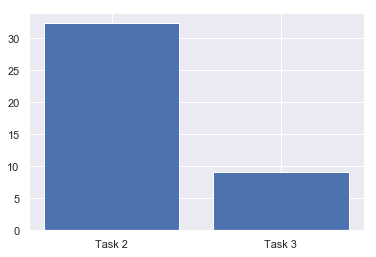

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


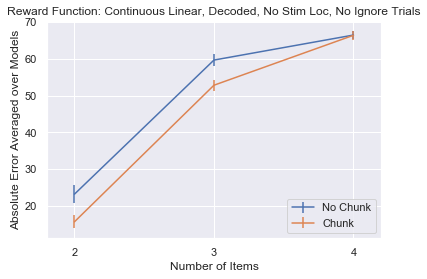

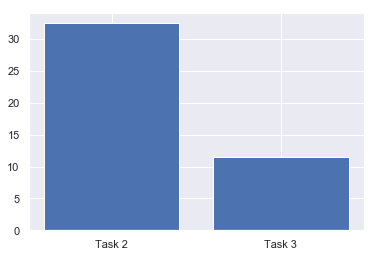

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


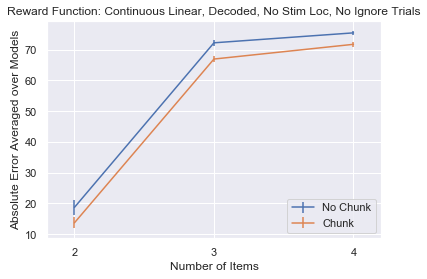

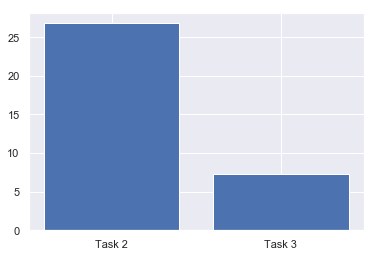

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/"
mse_allmodels(base,base2,experiment, sir4 =True)

80
80
80
80
80
80


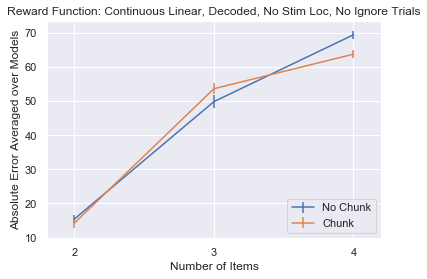

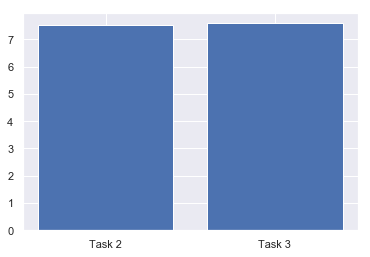

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


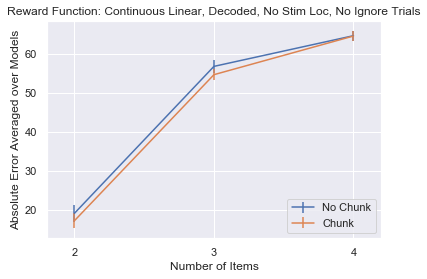

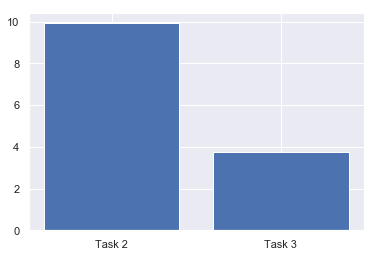

In [3]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


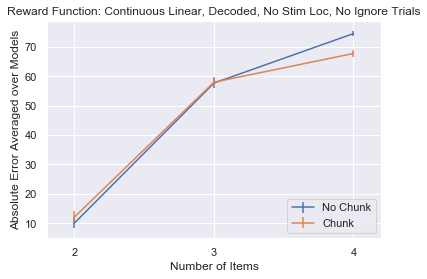

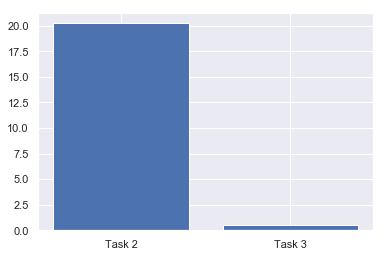

In [3]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/Burst1/Dip12/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


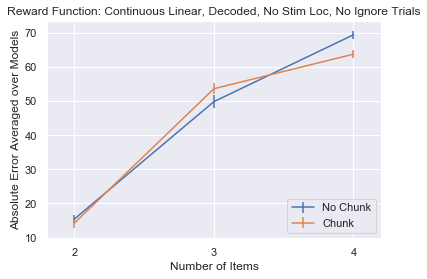

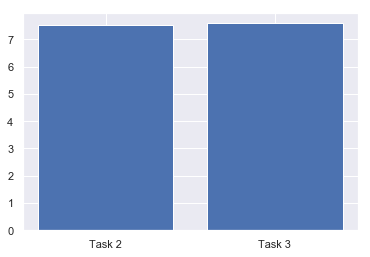

In [3]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
mse_allmodels(base,base2,experiment, sir4 = True)

In [ ]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma12/Test90/"
mse_allmodels(base,base2,experiment, sir4 = True)

In [ ]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/Test45/"
mse_allmodels(base,base2,experiment, sir4 = True)

In [ ]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/Test90/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


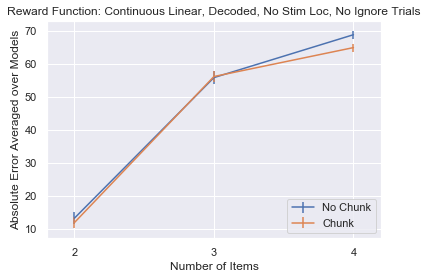

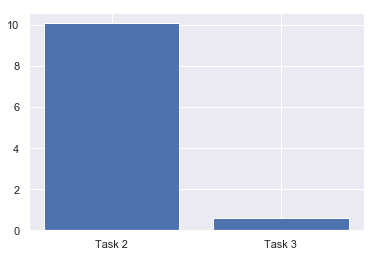

In [3]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma08/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


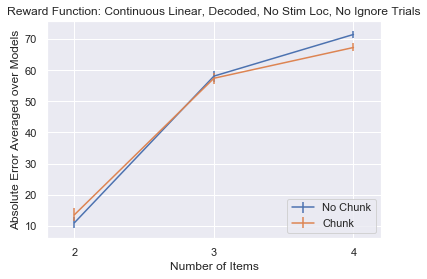

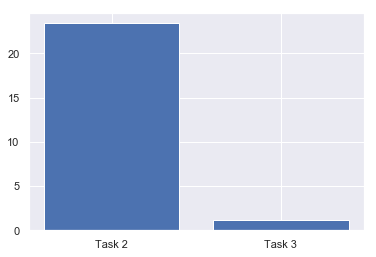

In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma1/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


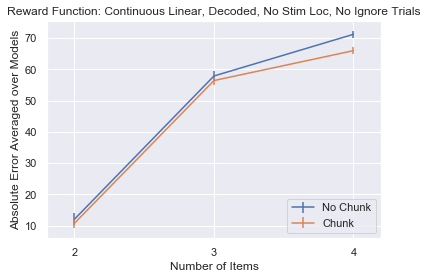

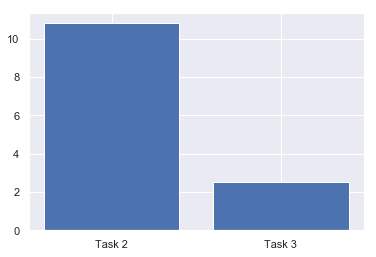

In [5]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/sigma12/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


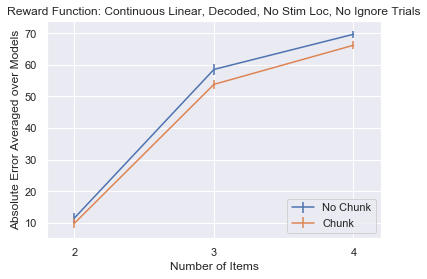

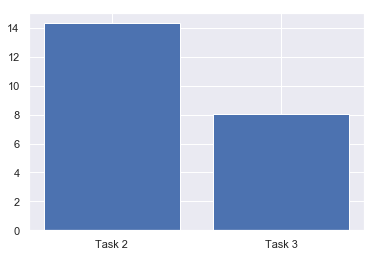

In [6]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment, sir4 = True)

20
20
20
20
20
20


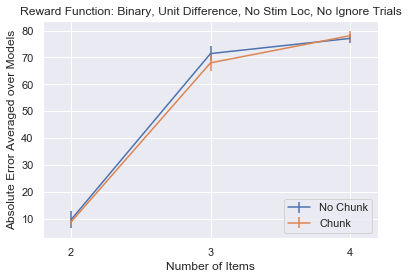

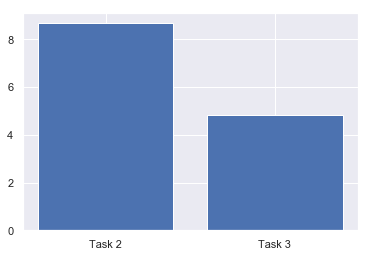

In [10]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "RewThresh55NoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment, sir4 = True)

20
20
20
20
20
20


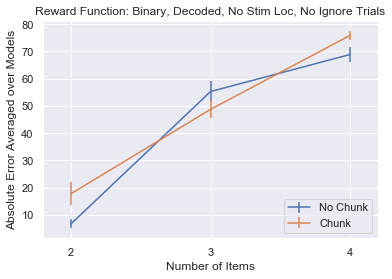

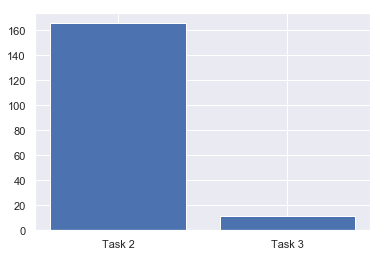

In [9]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/RewThresh30NoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
80
80


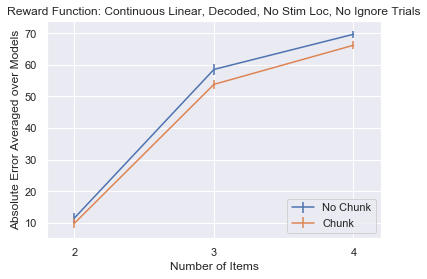

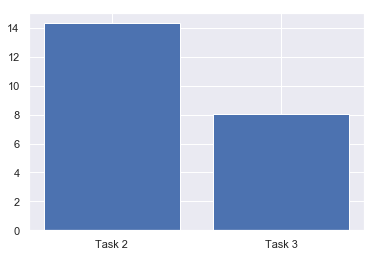

In [20]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80
20
20


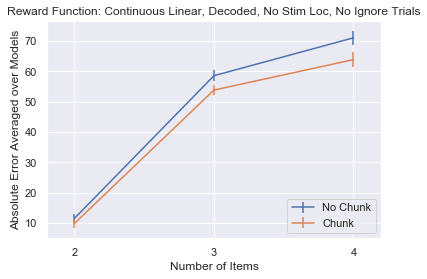

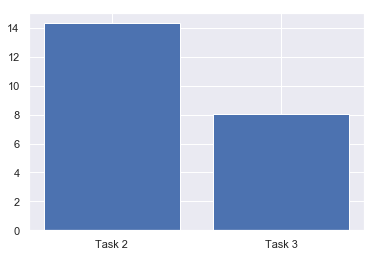

In [6]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment, sir4 = True)

80
80
80
80


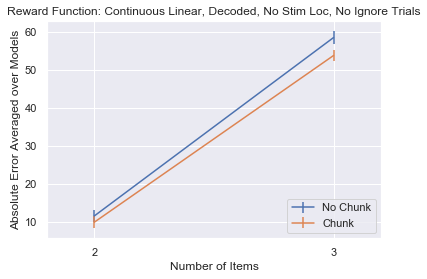

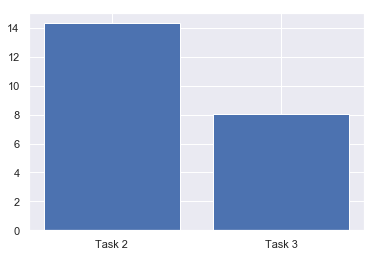

In [15]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)

80
80
80
80


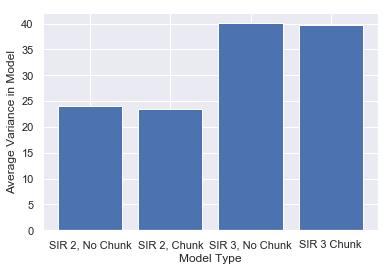

In [12]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/"
plot_var(base,base2,experiment)

80
80
80
80


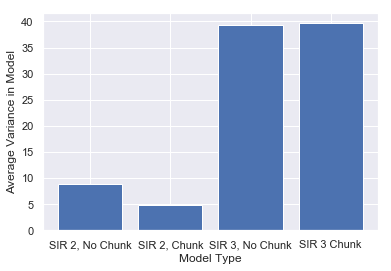

In [13]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
plot_var(base,base2,experiment)

80
80
80
80


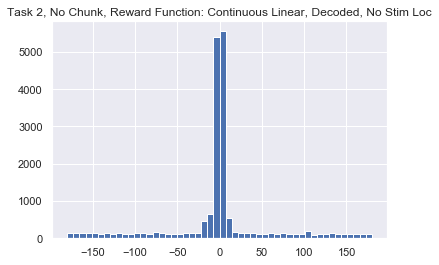

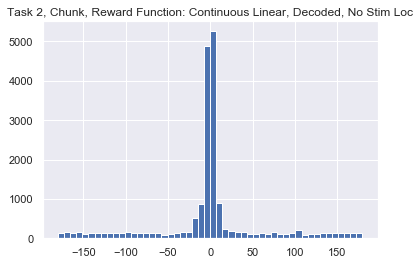

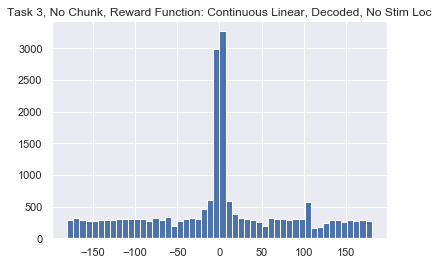

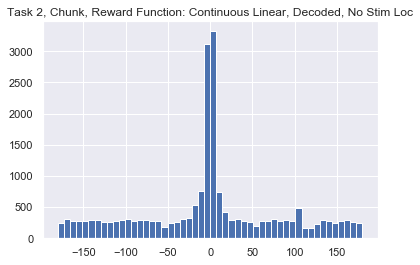

In [9]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/"
plot_allhist(base,base2,experiment)

80
80
80
80


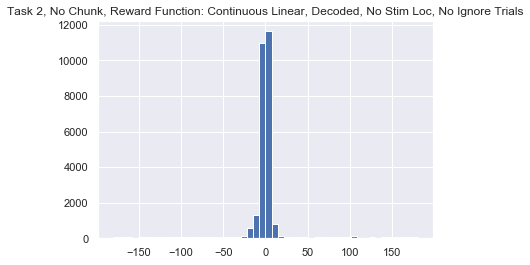

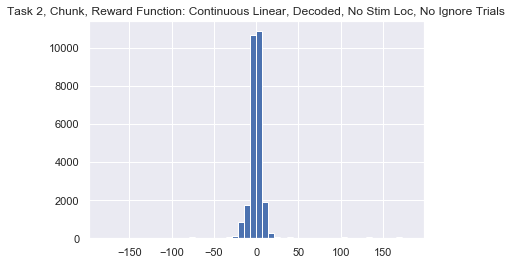

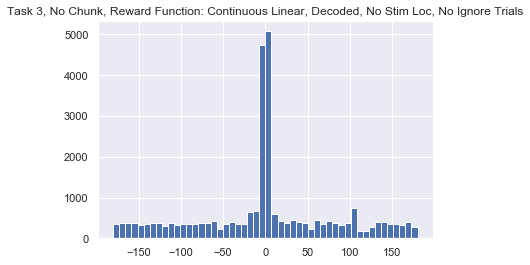

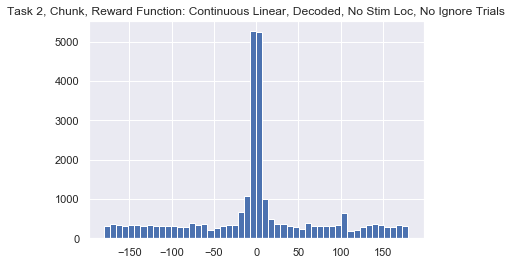

In [8]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
plot_allhist(base,base2,experiment)

20
20
20
20


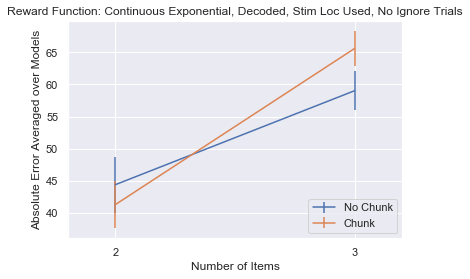

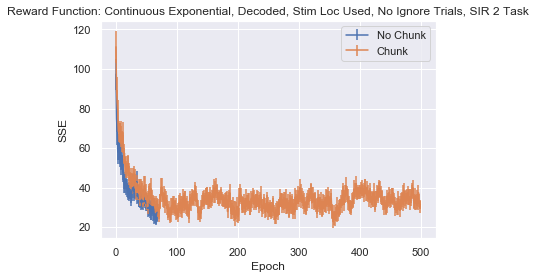

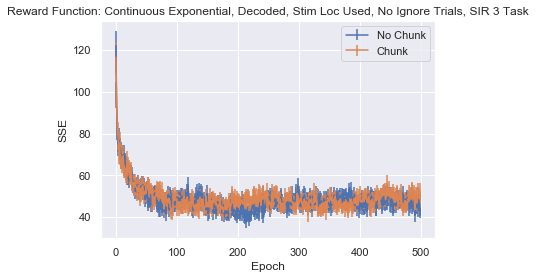

In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexp/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


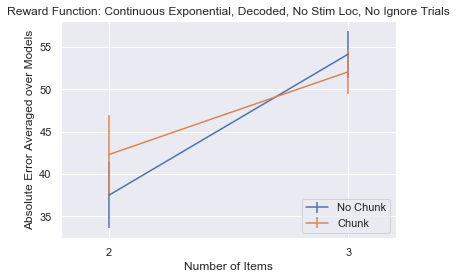

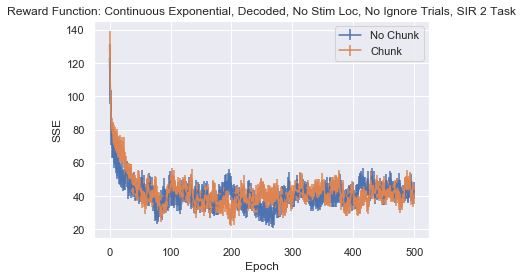

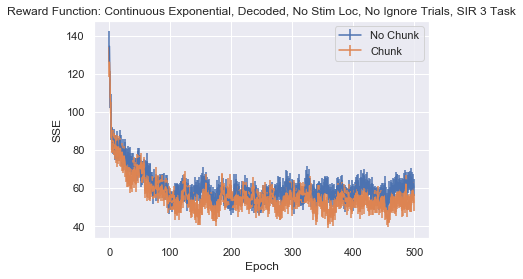

In [14]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexpNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


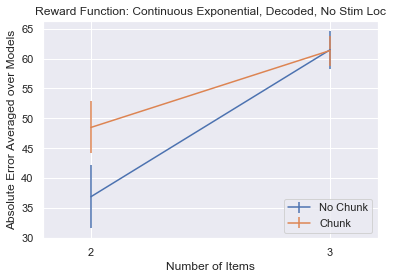

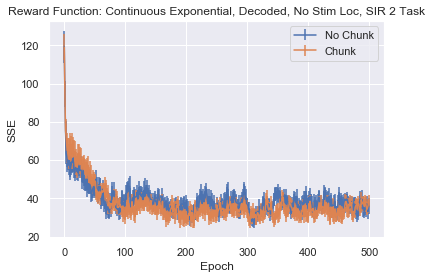

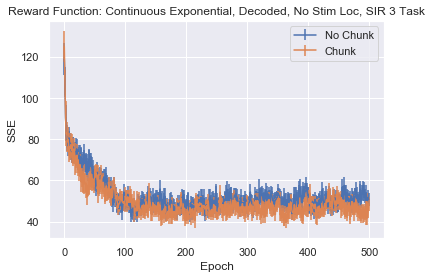

In [10]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexpNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


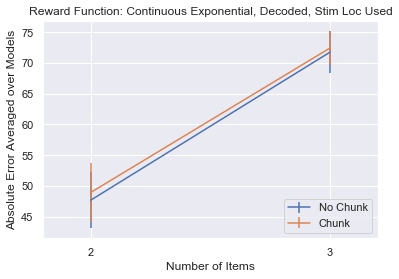

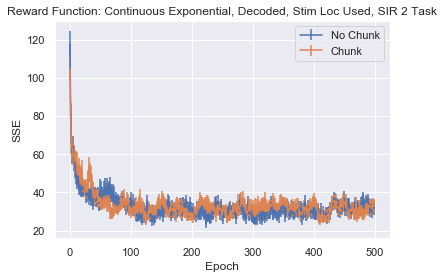

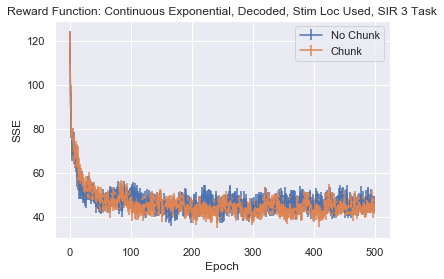

In [9]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexp/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


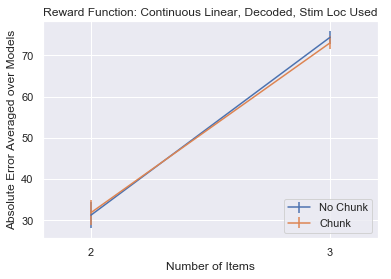

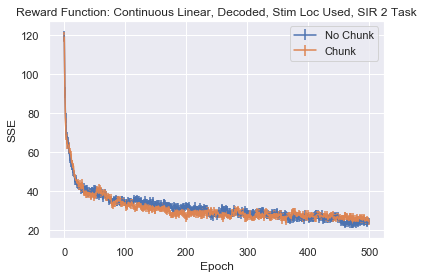

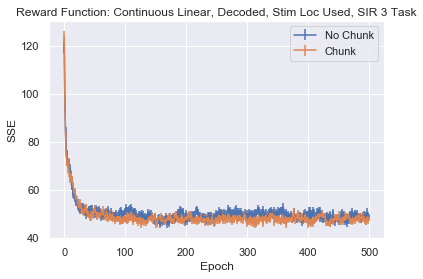

In [5]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


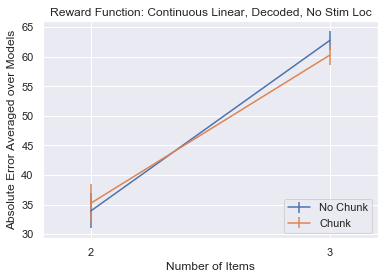

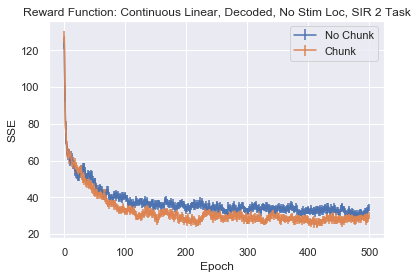

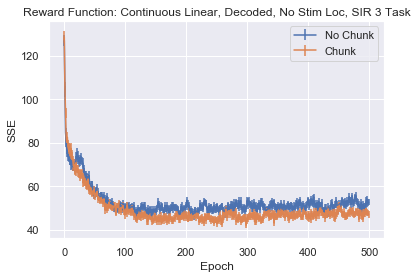

In [26]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


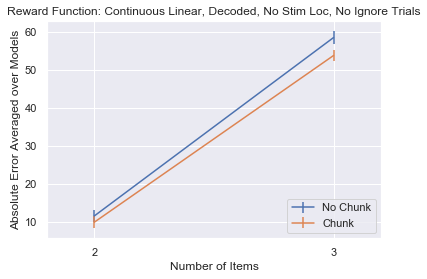

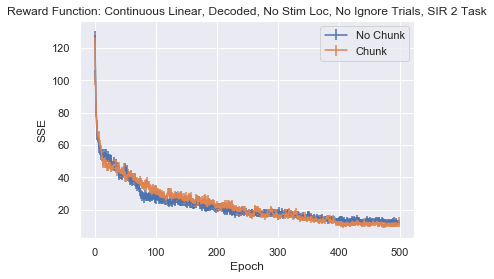

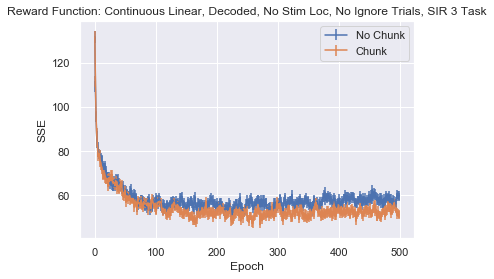

In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


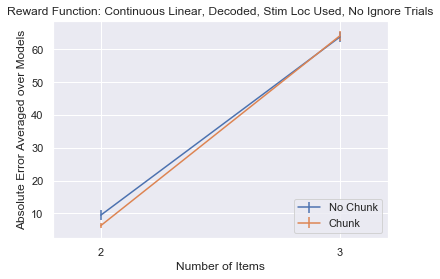

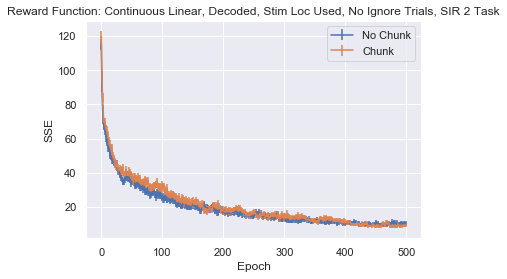

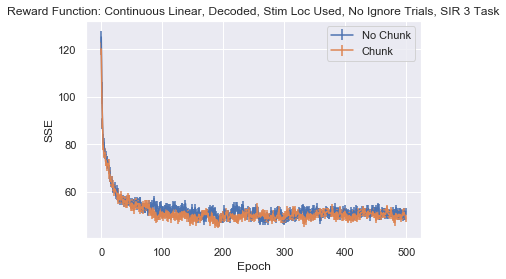

In [3]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


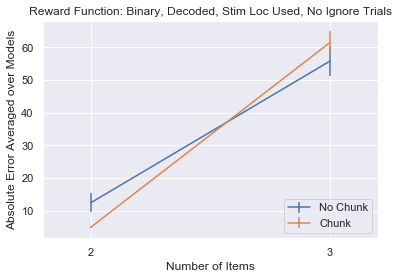

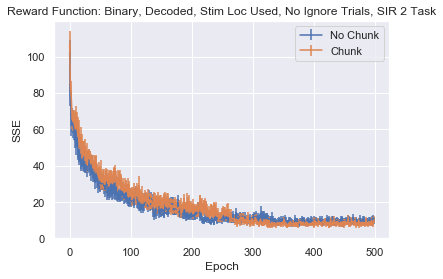

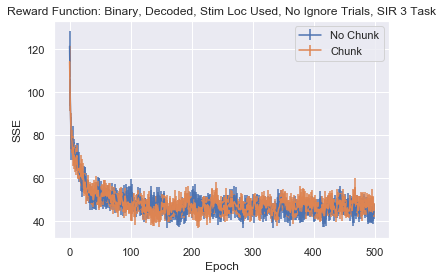

In [15]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/RewThresh30/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

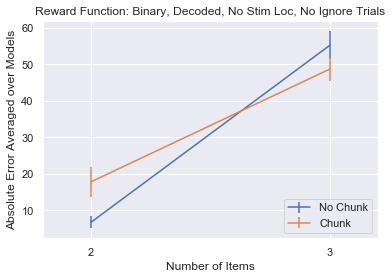

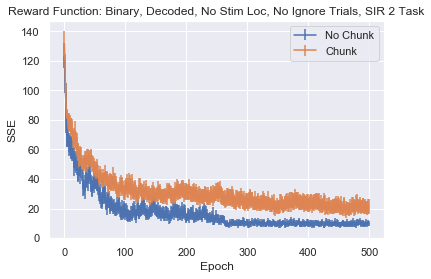

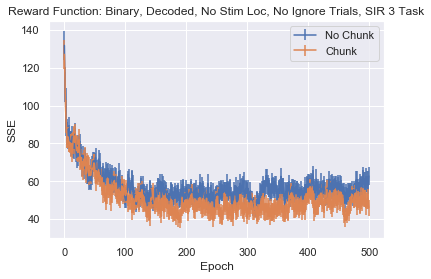

In [12]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/RewThresh30NoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

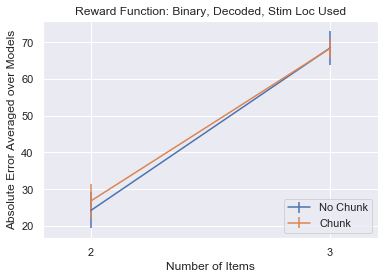

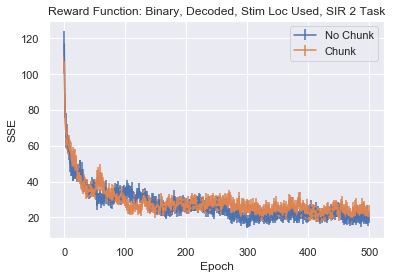

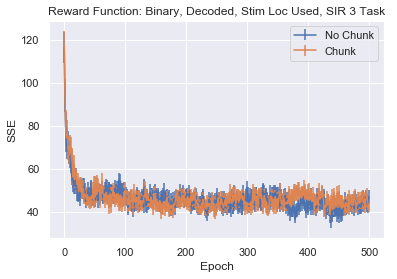

In [11]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/RewThresh30/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

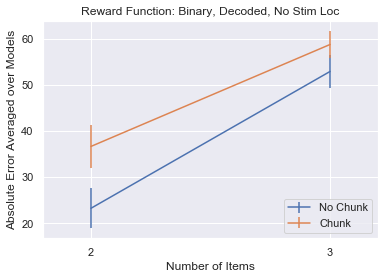

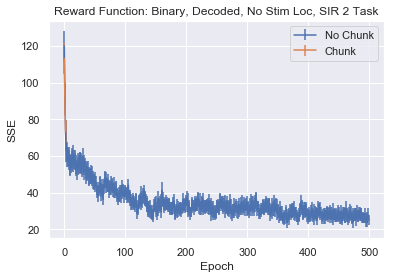

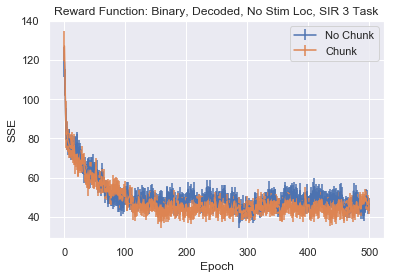

In [10]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/RewThresh30NoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


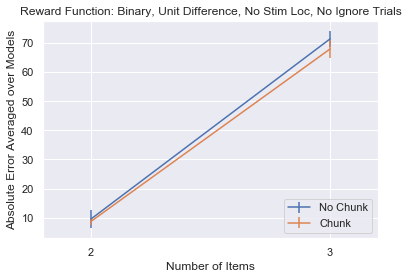

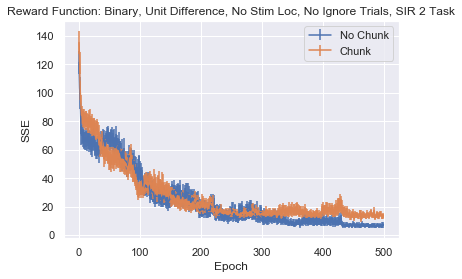

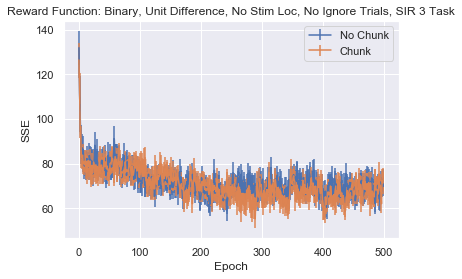

In [16]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "RewThresh55NoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


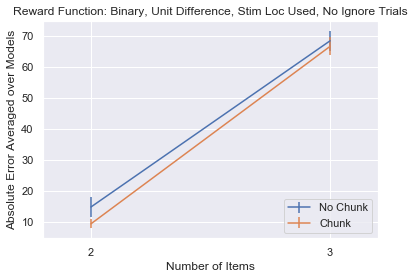

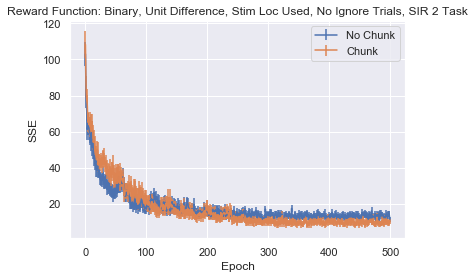

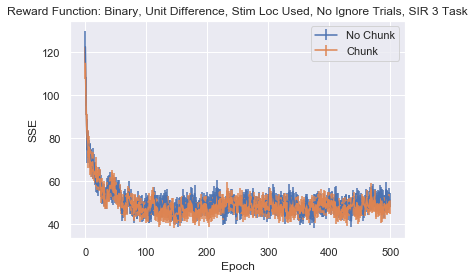

In [17]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "RewThresh55/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

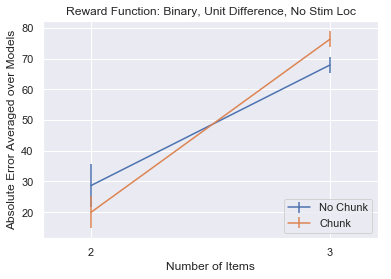

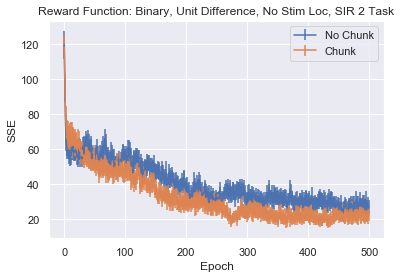

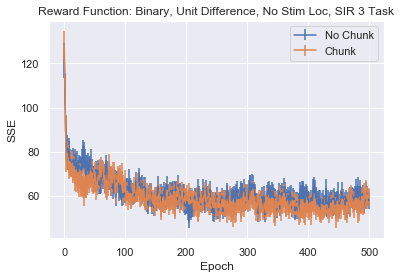

In [8]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "RewThresh55NoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

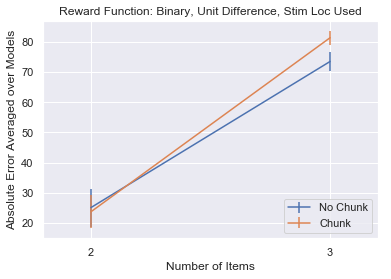

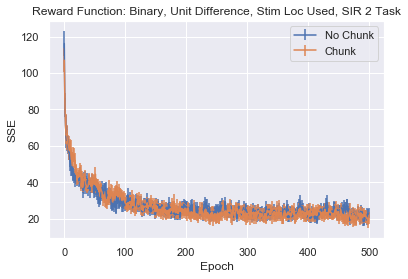

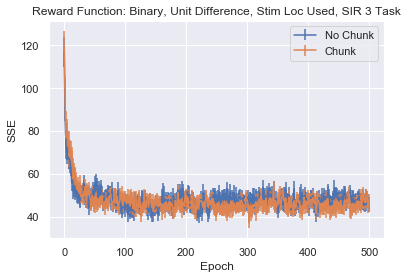

In [7]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "RewThresh55/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


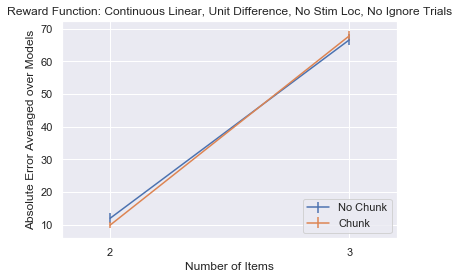

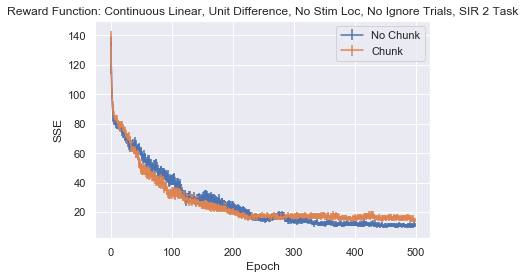

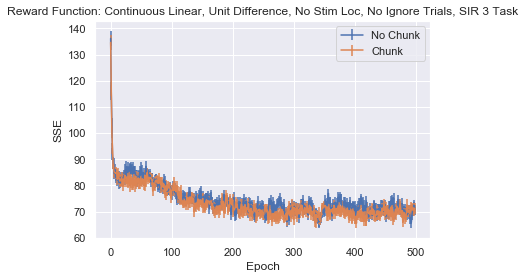

In [6]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

70
64
68
63


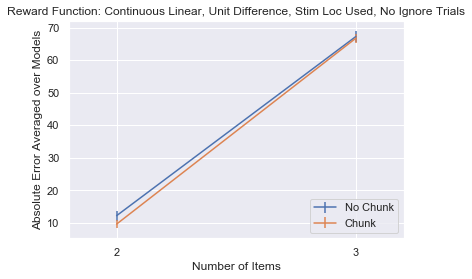

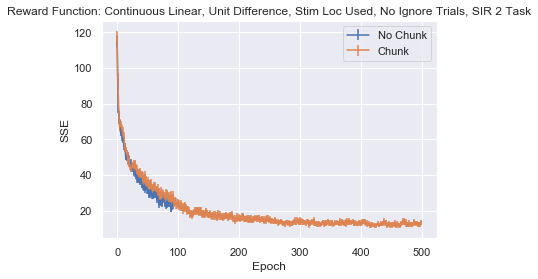

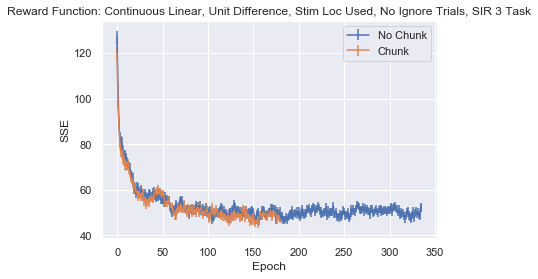

In [7]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "cont/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


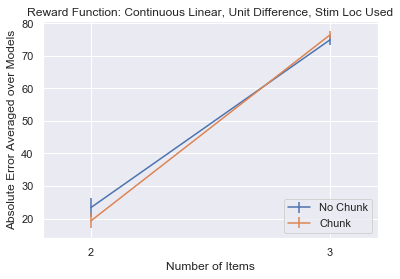

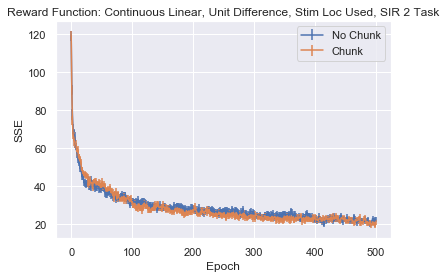

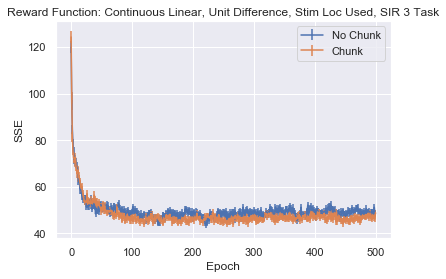

In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "cont/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

80
80
80
80


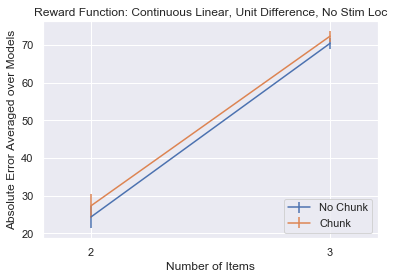

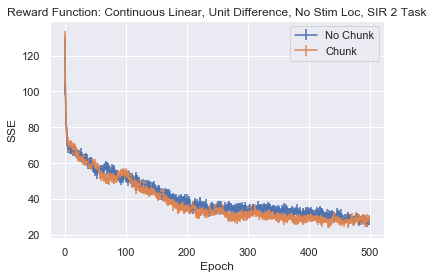

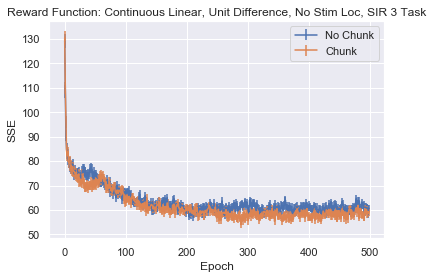

In [27]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


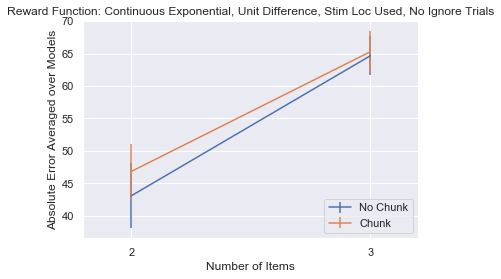

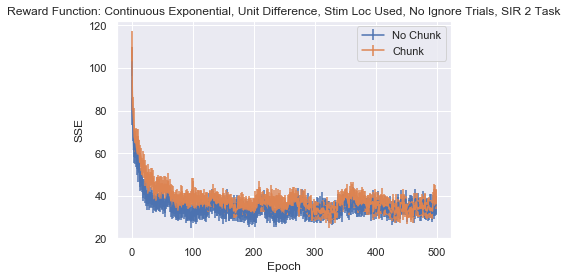

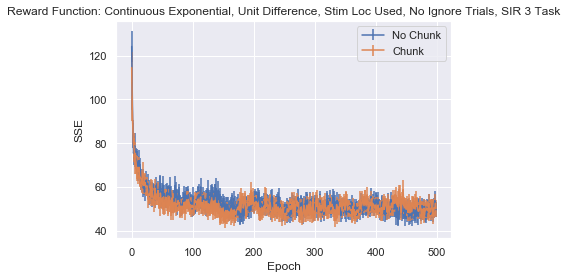

In [21]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexp/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

20
20
20
20


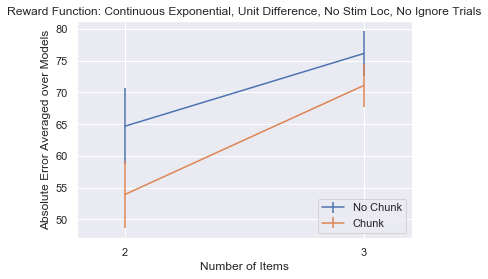

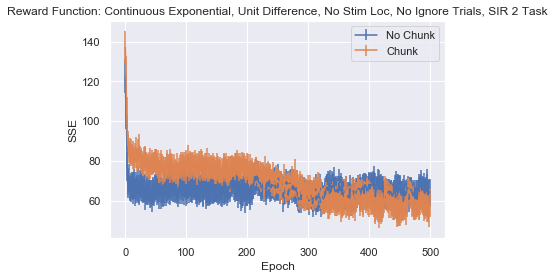

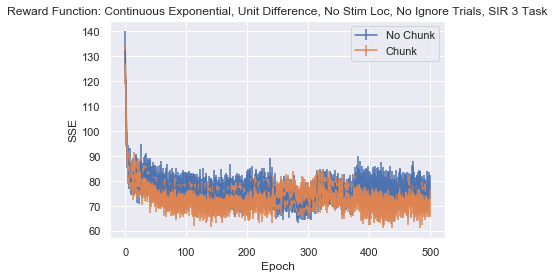

In [20]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexpNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

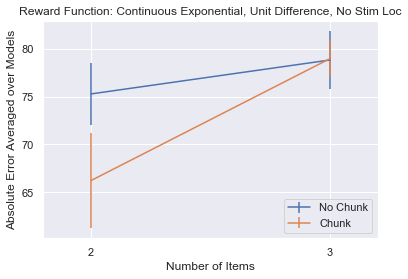

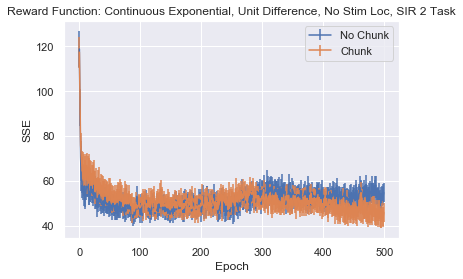

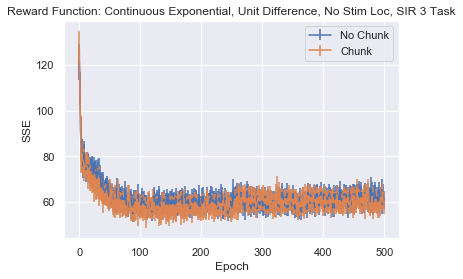

In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexpNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

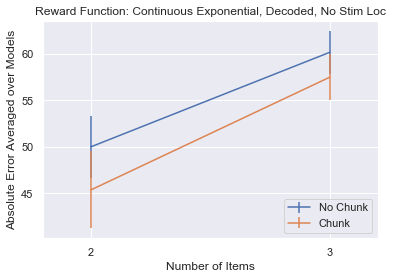

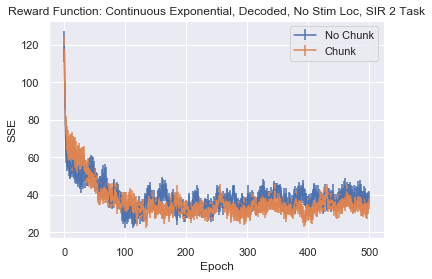

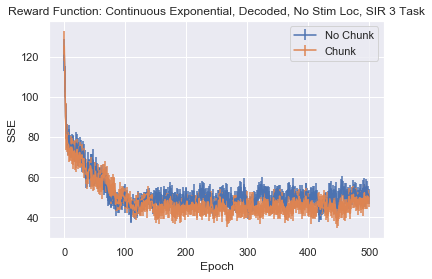

In [3]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexpNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

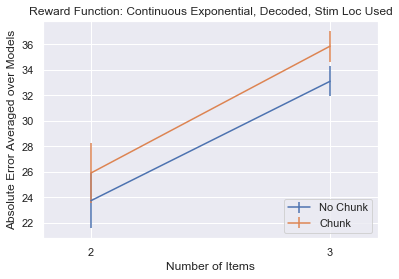

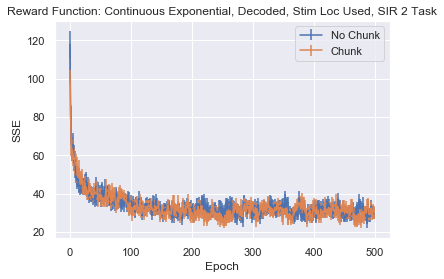

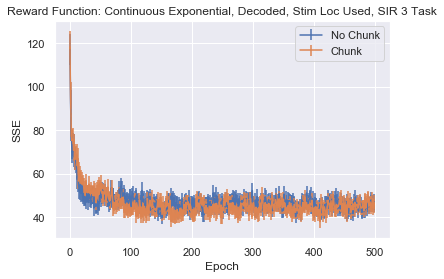

In [19]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexp/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

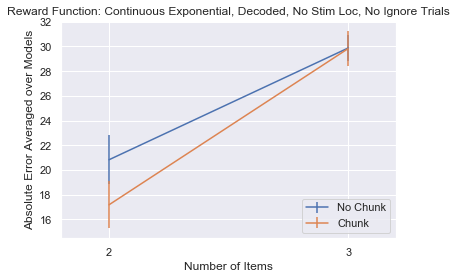

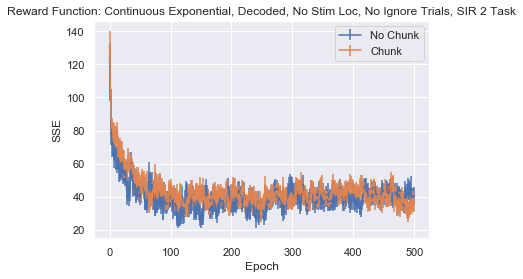

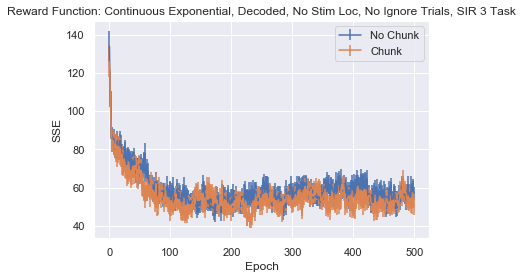

In [18]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexpNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

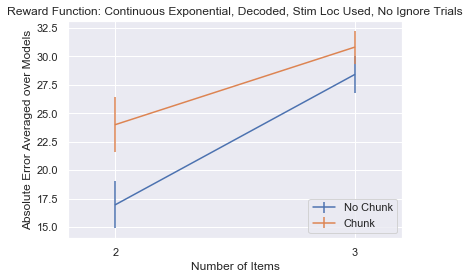

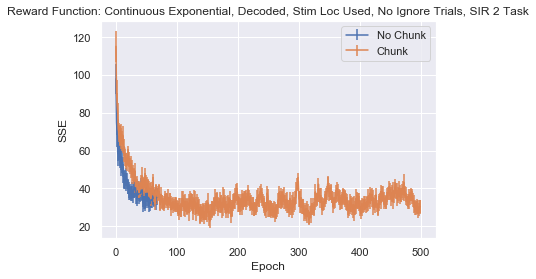

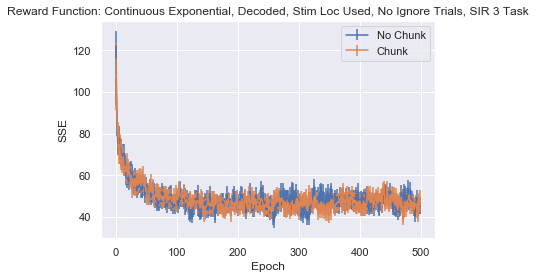

In [17]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contexp/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

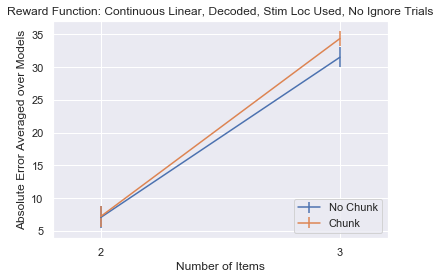

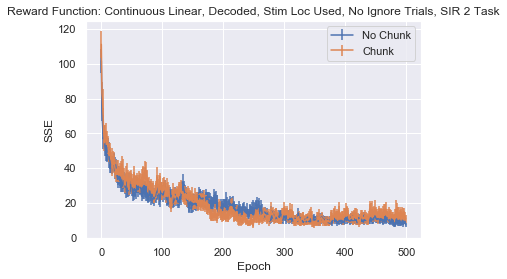

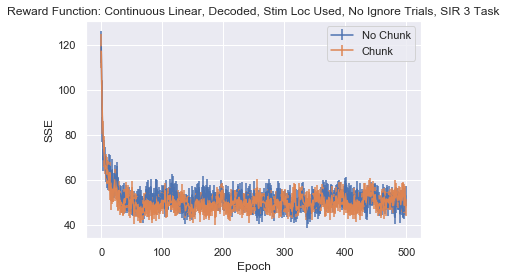

In [16]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

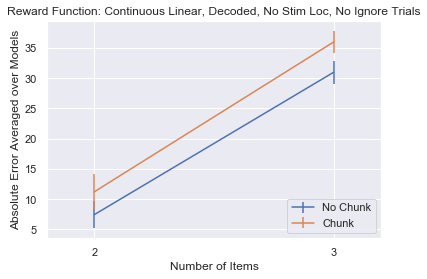

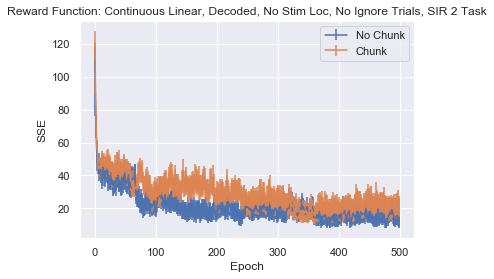

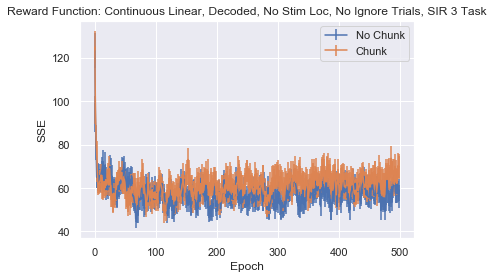

In [15]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

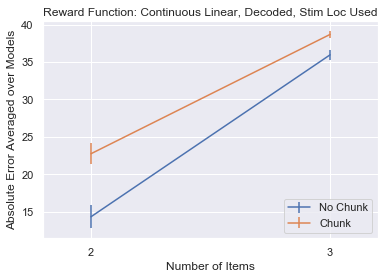

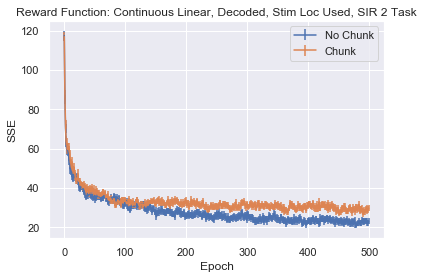

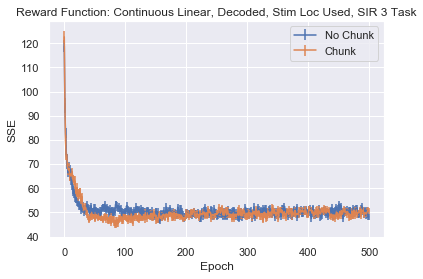

In [14]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

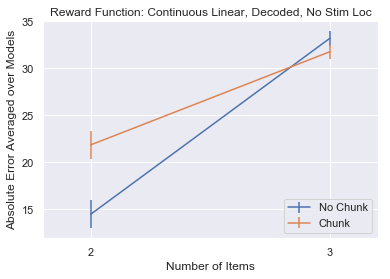

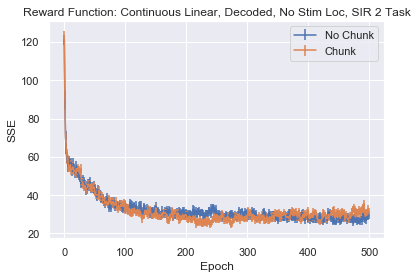

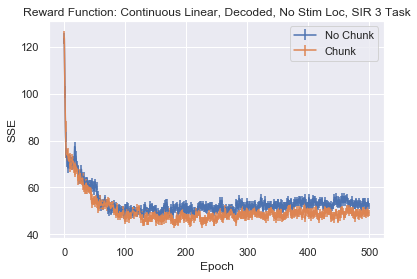

In [13]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

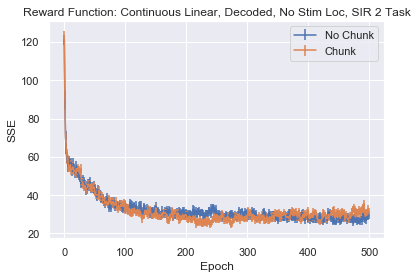

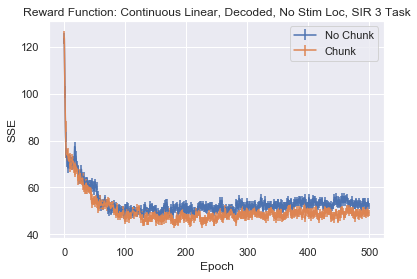

In [11]:

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/"
lc_allmodels(base,base2,experiment)

In [ ]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

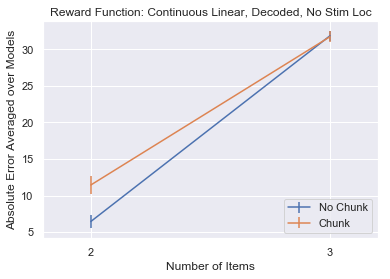

In [4]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/6Stripe/"
experiment = "decodedrew/contNoStimLoc/"
mse_allmodels(base,base2,experiment)
lc_allmodels(base,base2,experiment)

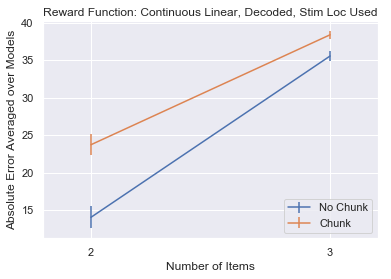

In [125]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/"
mse_allmodels(base,base2,experiment)

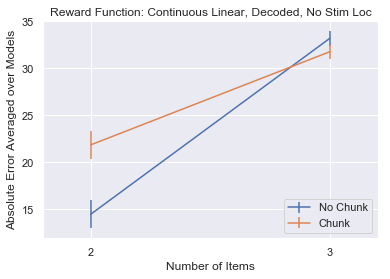

In [124]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/"
mse_allmodels(base,base2,experiment)

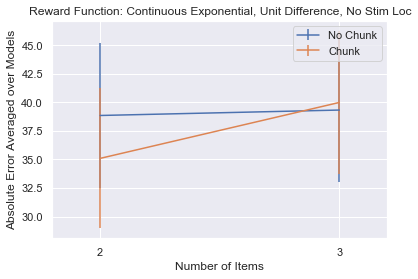

In [89]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexpNoStimLoc/"
mse_allmodels(base,base2,experiment)

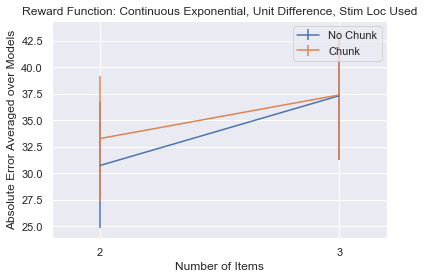

In [90]:

base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexp/"
mse_allmodels(base,base2,experiment)

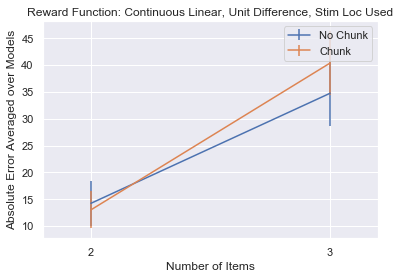

In [91]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "cont/"
mse_allmodels(base,base2,experiment)

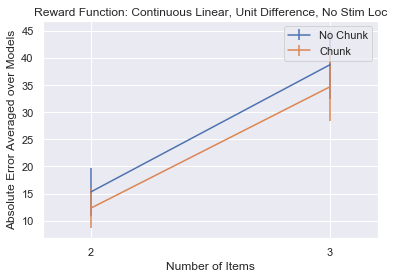

In [92]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/"
mse_allmodels(base,base2,experiment)

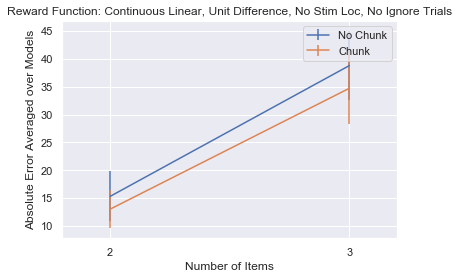

In [93]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)

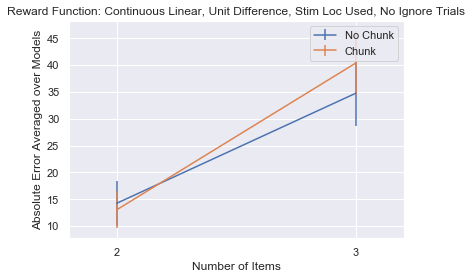

In [94]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "cont/NoIgnore/"
mse_allmodels(base,base2,experiment)

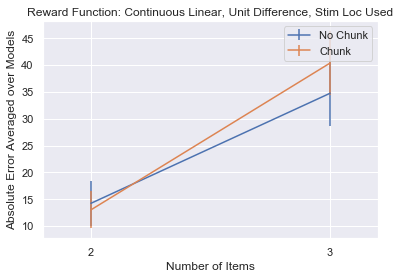

In [95]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "cont/"
mse_allmodels(base,base2,experiment)

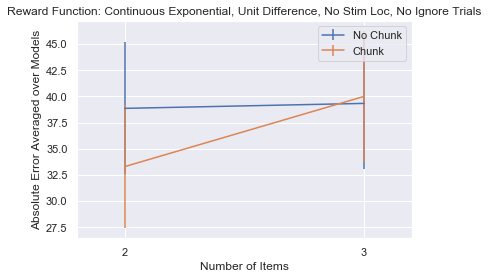

In [96]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexpNoStimLoc/NoIgnore/"
mse_allmodels(base,base2,experiment)

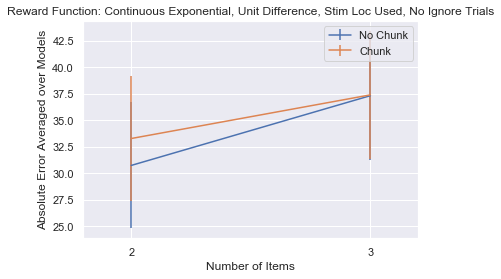

In [97]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "contexp/NoIgnore/"
mse_allmodels(base,base2,experiment)

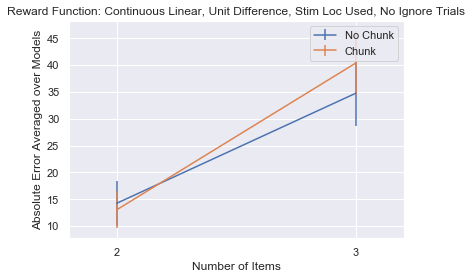

In [98]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "cont/NoIgnore/"
mse_allmodels(base,base2,experiment)